In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

In [48]:
df = pd.read_csv("data/test.csv", sep=";")

In [49]:
print(df.columns)

Index(['ID ANSSI', 'Titre ANSSI', 'Type', 'Date', 'CVE', 'Description CVE',
       'CVSS', 'Base severity', 'Vecteur de l'attaque',
       'Complexité de l'attaque', 'Privileges requis', 'Action utilisateur',
       'Impact sur la confidentialité', 'Impact sur l'intégrité',
       'Impact sur la disponibilité', 'CWE', 'EPSS', 'Lien CVE',
       'Lien solution', 'Description CWE', 'Editeur', 'Produit',
       'Versions affectées'],
      dtype='str')


TF-IDF :

In [50]:
description = df["Description CVE"].fillna("")                                    # fillna() remplace les Nan crée par pandas en str vide pour avoir un TF-IDF nul
vectorizer = TfidfVectorizer(stop_words='english',  max_features=10_000)          # stop_words='english' pour ignorer les mots vides en anglais
tf_idf = vectorizer.fit_transform(description)                                    # Calcul des TF-IDF pour chaque description



mean_tfidf = np.asarray(tf_idf.mean(axis=0)).ravel()
top_indices = np.argsort(mean_tfidf)[::-1][:10000]                               # On séléctionne les 10000 les plus importants

tf_idf_filtered = tf_idf[:, top_indices]                                         # On filtre avant toarray pour améliorer la compléxité
vocab_filtered = vectorizer.get_feature_names_out()[top_indices]

df_tfidf = pd.DataFrame(tf_idf_filtered.toarray(), columns=vocab_filtered)       # toarray() transforme cahque ligne en liste. On obtient une matrice avec toutes les descriptions


df_tfidf.head()

,kernel,vulnerability,linux,fix,null,following,resolved,use,net,memory,...,72747,0aa00,75721,hfsplus_read_wrapper,__hfsplus_ext_cache_extent,t1897,fl_walk,hfsplus_strcasecmp,cp200,hfsplus_bnode_read
0,0.0,0.106123,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.028980,0.0,0.088112,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.041561,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.111393,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Silhouette Score

In [51]:
results = []

for k in range(2,60):                                                                               # On teste différentes valeurs de k
    KMean = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=10)                               # On applique Kmeans par batch pour limiter le temps d'éxécution
    labels = KMean.fit_predict(tf_idf)                                                              # On applique le KMeans sur la mtrice tf_idf
    echantillon = np.random.choice(tf_idf.shape[0], size=5000, replace=False)                       # Échantillon de 5000 points pour ne pas faire exploser le temps de calcul
    score = silhouette_score(tf_idf[echantillon], labels[echantillon], metric='cosine')             # On calcule le silhouette score avec k clusters pour 5000

    results.append({"k": k, "inertia": KMean.inertia_, "silhouette": score})
    print(f"k={k} → inertie={KMean.inertia_:.0f} | silhouette={score:.4f}")

df_results = pd.DataFrame(results)                                                                  # On crée un DF pour les résultats

best_k = df_results.loc[df_results["silhouette"].idxmax(), "k"]                                     # On récupére le meilleur k
print(f"Meilleur K : {best_k} (silhouette={df_results['silhouette'].max():.4f})")

k=2 → inertie=121903 | silhouette=0.0194
k=3 → inertie=120907 | silhouette=0.0212
k=4 → inertie=120076 | silhouette=0.0206
k=5 → inertie=119667 | silhouette=0.0182
k=6 → inertie=118155 | silhouette=0.0282
k=7 → inertie=117977 | silhouette=0.0293
k=8 → inertie=116706 | silhouette=0.0279
k=9 → inertie=116927 | silhouette=0.0312
k=10 → inertie=116187 | silhouette=0.0342
k=11 → inertie=114971 | silhouette=0.0455
k=12 → inertie=114855 | silhouette=0.0435
k=13 → inertie=113755 | silhouette=0.0492
k=14 → inertie=113952 | silhouette=0.0490
k=15 → inertie=113527 | silhouette=0.0515
k=16 → inertie=113300 | silhouette=0.0484
k=17 → inertie=113431 | silhouette=0.0495
k=18 → inertie=112993 | silhouette=0.0479
k=19 → inertie=112961 | silhouette=0.0471
k=20 → inertie=113381 | silhouette=0.0514
k=21 → inertie=111514 | silhouette=0.0595
k=22 → inertie=111904 | silhouette=0.0557
k=23 → inertie=111256 | silhouette=0.0597
k=24 → inertie=111473 | silhouette=0.0545
k=25 → inertie=110895 | silhouette=0.0493


KMeans

In [52]:
model = MiniBatchKMeans(n_clusters=best_k, random_state=42)
model.fit(tf_idf)
df["cluster"] = model.labels_

Graphique des clusters

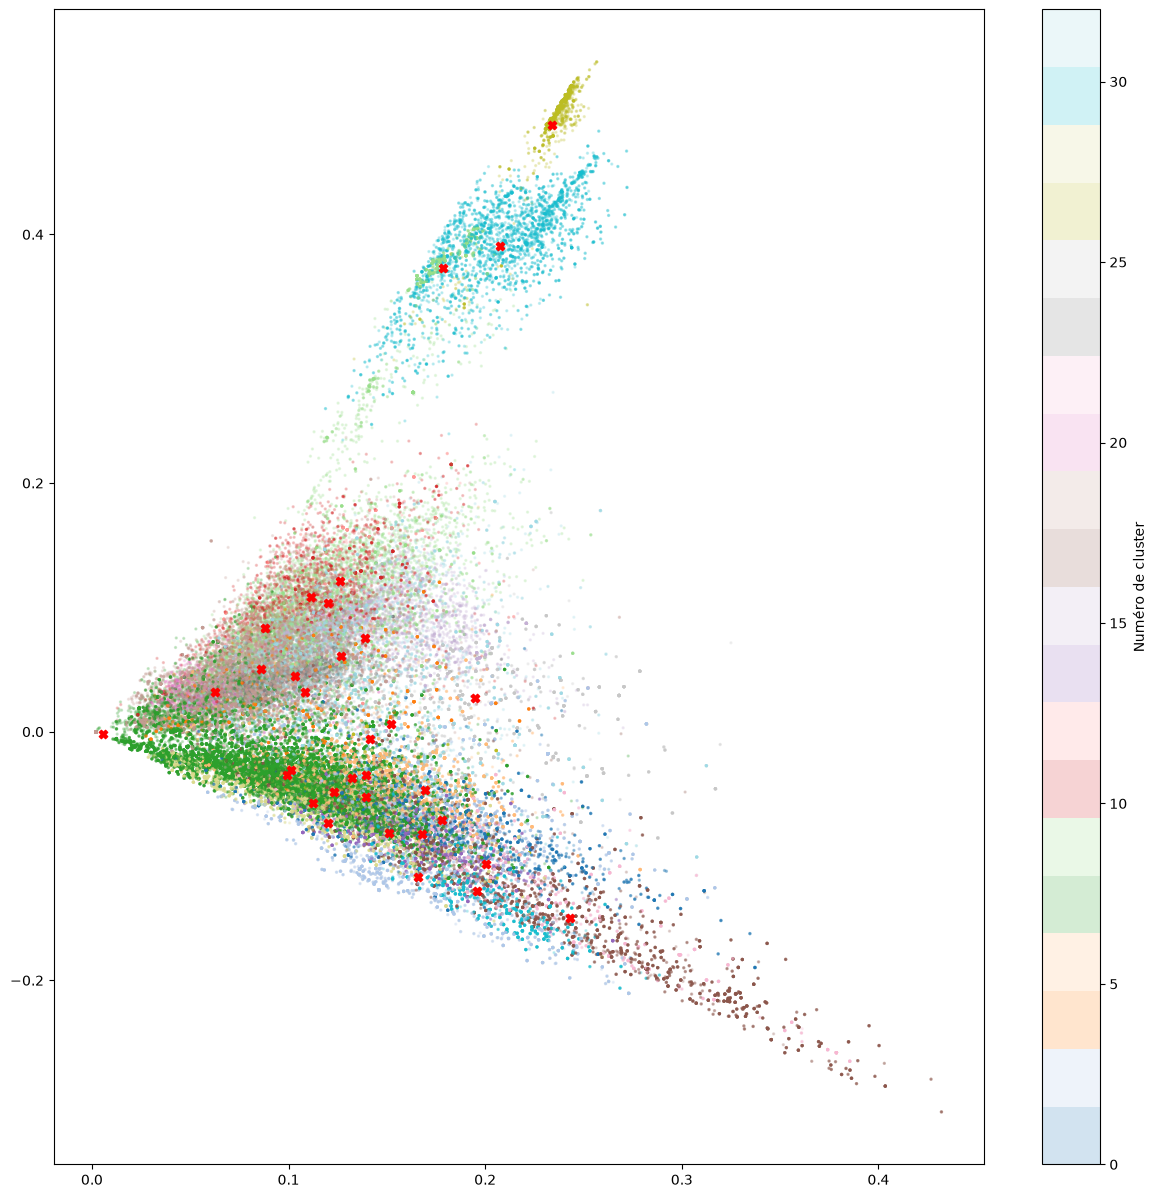

In [53]:
svd = TruncatedSVD(n_components=2, random_state=42)
tf_idf_2d = svd.fit_transform(tf_idf)                        # Réduit toutes les 125K lignes en 2D
centroids_2d = svd.transform(model.cluster_centers_)         # (best_k x 2)

plt.figure(figsize=(15, 15))
scatter = plt.scatter(
    tf_idf_2d[:, 0],                                        # Toutes les lignes, colonne 0
    tf_idf_2d[:, 1],                                        # Toutes les lignes, colonne 1
    c=df["cluster"].values,                                 # Couleur = numéro de cluster
    cmap='tab20',
    alpha=0.2,                                              # On augmente la transaparence des points pour mieux voir les clusters
    s=2                                                     # Points très petits pour 125K points
)


plt.scatter(centroids_2d[:, 0],centroids_2d[:, 1],c='red',marker='X')

plt.colorbar(scatter, label="Numéro de cluster")
plt.savefig("clusters_kmeans.png", dpi=150)
plt.show()

Prédire la classe

In [97]:
nouvelle_description = vectorizer.transform(["Buffer overflow in Apache allowing remote code execution"])
nd_predict = model.predict(nouvelle_description)[0]
print(nd_predict)

32


In [111]:
cluster_mask = (df["cluster"] == nd_predict).values                                     # On crée un mask pour récuperer les descriptions du meme cluster
cluster_vecs = tf_idf[cluster_mask]

similarities = cosine_similarity(nouvelle_description, cluster_vecs).ravel()            # cosine_similarity calcule la similitude entre la nouvelle description et toutes les descriptions du cluster.
                                                                                        # ravel() transforme le résultat en 1D

top_indices = np.argsort(similarities)[::-1][:2]                                        # argsort donne les elements avec la similitude du plus bas au plus haut et on inverse avec [::-1].
                                                                                        # [:2] nous donne les 2premiéres colonne

results = df[cluster_mask].iloc[top_indices].copy()                                     # On récupére les lignes de top_indices

results

,ID ANSSI,Titre ANSSI,Type,Date,CVE,Description CVE,CVSS,Base severity,Vecteur de l'attaque,Complexité de l'attaque,...,Impact sur la disponibilité,CWE,EPSS,Lien CVE,Lien solution,Description CWE,Editeur,Produit,Versions affectées,cluster
40537,CERTFR-2024-AVI-1042,Multiples vulnérabilités dans Sonicwall Secure...,Avis,2024-12-05T00:00:00.000000,CVE-2024-53703,A vulnerability in the SonicWall SMA100 SSLVPN...,NaN,NaN,NaN,NaN,...,NaN,CWE-121,0.29148,https://www.cve.org/CVERecord?id=CVE-2024-53703,https://psirt.global.sonicwall.com/vuln-detail...,CWE-121 Stack-based Buffer Overflow,SonicWall,SMA100,10.2.1.13-72sv and earlier versions,32
40539,CERTFR-2024-AVI-1042,Multiples vulnérabilités dans Sonicwall Secure...,Avis,2024-12-05T00:00:00.000000,CVE-2024-40763,Heap-based buffer overflow vulnerability in th...,NaN,NaN,NaN,NaN,...,NaN,CWE-122,0.08234,https://www.cve.org/CVERecord?id=CVE-2024-40763,https://psirt.global.sonicwall.com/vuln-detail...,CWE-122 Heap-based Buffer Overflow,SonicWall,SMA100,10.2.1.13-72sv and earlier versions,32
